# Day 13: Backtesting, Monte Carlo, and Allocation Overlay

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 13.

Builds the regime-conditioned Monte Carlo engine (A13.1, A13.2), a
regime-and-conviction-conditioned allocation overlay, backtests it over
2019-2024, and generates the Investment Committee artefact (A13.3) with
full lineage.

**A methodological decision made explicit before any numbers, not
after**: a genuinely point-in-time-valid backtest needs a model fit
using ONLY data available before the window starts. Day 4's published
5-state HMM was fit on the full 15-year series (including 2025 data,
"future" relative to 2019-2024) - reusing it here would repeat the same
parameter-level look-ahead bias Day 9 flagged prominently for several of
its ensemble members. Refitting on pre-2019 data alone was attempted at
K=5 (fails outright, 0/30 valid restarts) and K=3 (technically fits but
degenerates into two single-day outlier-catching states, not real
regimes). **K=2 is the most states this 8-year window robustly
supports** (30/30 valid restarts, two genuinely persistent states) - a
further, independent confirmation of Day 4's "simpler models are more
robust with limited data" finding, not a convenience fallback.

The backtest therefore uses a Calm/Crisis dichotomy, not the full
5-state taxonomy. A secondary, clearly-labelled comparison later in this
notebook reuses Day 4's full 5-state model to make a separate, different
point about Post-Shock concrete - it carries the look-ahead bias the
whole K=2 exercise exists to avoid, and is not the headline backtest.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.plot_style import new_figure, PALETTE
from src.models.monte_carlo.regime_mc import RegimeConditionedMC, regime_var
from src.models.monte_carlo.ic_artefact import Lineage, build_ic_artefact, conditional_on_state_statement
from src.backtest.overlay import tilt_probability_weighted, tilt_conviction_scaled, regime_sharpe_proxy

pd.set_option('display.precision', 4)

## 1. The point-in-time HMM fit: why K=2

In [2]:
import warnings; warnings.filterwarnings('ignore')
from src.data.loader import DataConfig, load_market_data
from src.models.hmm.frequentist import fit_regime_hmm_robust

data = load_market_data(DataConfig(backend='synthetic', n_years=15.0, seed=7))
returns_full = data['nifty50']['close'].pct_change().dropna()
pre_window = returns_full.loc[:'2018-12-31']

for k in [5, 3, 2]:
    try:
        model_k, states_k, _, seed_k, nvalid_k = fit_regime_hmm_robust(pre_window, n_states=k, n_restarts=30, base_seed=42)
        occ = np.bincount(states_k, minlength=k)
        print(f"K={k}: seed={seed_k} valid={nvalid_k}/30  occupancy={occ.tolist()}  diag={model_k.transmat_.diagonal().round(3).tolist()}")
    except RuntimeError as e:
        print(f"K={k}: FAILED - {e}")

Model is not converging.  Current: 6690.361236576552 is not greater than 6690.408159848414. Delta is -0.04692327186148759


Model is not converging.  Current: 6692.202369092811 is not greater than 6692.991310682137. Delta is -0.7889415893259866


Model is not converging.  Current: 6693.514206001523 is not greater than 6693.529903763284. Delta is -0.015697761760748108


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


...

Model is not converging.  Current: 6695.968503808409 is not greater than 6696.096357631724. Delta is -0.12785382331458095


Model is not converging.  Current: 6696.0288405789815 is not greater than 6696.131514447693. Delta is -0.102673868711463


Model is not converging.  Current: 6695.990381396557 is not greater than 6696.110934619944. Delta is -0.12055322338710539


Model is not converging.  Current: 6695.99083886175 is not greater than 6696.110712881672. Delta is -0.11987401992246305


K=2: seed=61 valid=30/30  occupancy=[2015, 70]  diag=[0.999, 0.977]


K=5 fails outright. K=3 fits but two of its three states have
zero self-transition probability and occupy only 35 days each out of
2085 - single-day outlier catchers, not multi-day regimes. K=2 is
robust (30/30) with two genuinely persistent states. This is the model
used for the headline backtest below.

In [3]:
model, states_pre, probs_pre, seed_used, n_valid = fit_regime_hmm_robust(pre_window, n_states=2, n_restarts=30, base_seed=42)
label_map = {i: ('Calm' if model.means_[i, 0] > 0 else 'Crisis') for i in range(2)}
calm_idx = [k for k, v in label_map.items() if v == 'Calm'][0]
crisis_idx = 1 - calm_idx
drift_ann = model.means_[:, 0] * 252
vol_ann = np.sqrt(model.covars_.reshape(2, 1)[:, 0]) * np.sqrt(252)
print(f"Calm  (idx {calm_idx}): drift={drift_ann[calm_idx]:+.3f}  vol={vol_ann[calm_idx]:.3f}")
print(f"Crisis (idx {crisis_idx}): drift={drift_ann[crisis_idx]:+.3f}  vol={vol_ann[crisis_idx]:.3f}")
print(f"Fit on {pre_window.index.min().date()} to {pre_window.index.max().date()} ({len(pre_window)} days), seed={seed_used}, {n_valid}/30 valid")

Model is not converging.  Current: 6696.011266152894 is not greater than 6696.105153550499. Delta is -0.09388739760561293


Model is not converging.  Current: 6695.939467082969 is not greater than 6696.027488904921. Delta is -0.08802182195177011


Model is not converging.  Current: 6696.014456176725 is not greater than 6696.126693884173. Delta is -0.11223770744800277


Model is not converging.  Current: 6695.986510451061 is not greater than 6696.10928868176. Delta is -0.12277823069871374


Model is not converging.  Current: 6696.0008459837745 is not greater than 6696.0834600167045. Delta is -0.08261403292999603


...

Model is not converging.  Current: 6695.968503808409 is not greater than 6696.096357631724. Delta is -0.12785382331458095


Model is not converging.  Current: 6696.0288405789815 is not greater than 6696.131514447693. Delta is -0.102673868711463


Model is not converging.  Current: 6695.990381396557 is not greater than 6696.110934619944. Delta is -0.12055322338710539


Model is not converging.  Current: 6695.99083886175 is not greater than 6696.110712881672. Delta is -0.11987401992246305


Calm  (idx 0): drift=+0.118  vol=0.153
Crisis (idx 1): drift=-1.121  vol=0.358
Fit on 2011-01-04 to 2018-12-31 (2085 days), seed=61, 30/30 valid


## 2. The allocation overlay: 2019-2024 backtest

Filtered (causal) regime probabilities from this point-in-time-fit
model, sliced to 2019-2024 - no look-ahead at the parameter level (fit
on pre-2019 data only) or the probability level (filtered, not
smoothed).

In [4]:
results = json.load(open('../artifacts_data/day13_backtest_results.json'))
pd.DataFrame(results['backtest_results']).T.style.format({
    'total_return': '{:+.2%}', 'annualized_return': '{:+.2%}', 'annualized_vol': '{:.2%}',
    'max_drawdown': '{:.2%}', 'information_ratio_vs_buy_hold': '{:.3f}', 'tracking_error_vs_buy_hold': '{:.2%}',
})

,total_return,annualized_return,annualized_vol,max_drawdown,information_ratio_vs_buy_hold,tracking_error_vs_buy_hold
prob_weighted,-10.27%,-1.73%,14.15%,-36.53%,0.157,3.45%
conviction_scaled,-10.82%,-1.83%,15.58%,-39.34%,0.232,2.81%
naive_name_based,-8.46%,-1.41%,12.38%,-32.49%,0.134,4.68%
buy_hold,-15.06%,-2.59%,16.41%,-41.09%,nan,0.00%


**The underlying price path here is synthetic, not real Nifty - this
point cannot be restated too often given how easy it is to misread a
backtest table.** All strategies lose money over this particular
2019-2024 slice, including buy-hold (-15.1%); the REAL Nifty roughly
doubled over the real 2019-2024 period. This reflects the synthetic
generator's own random regime draw for this calendar window, which has
no relationship to actual market history, not a claim about what really
happened. What the table DOES show validly: all three overlay variants
reduce drawdown and improve the information ratio relative to the same
synthetic buy-hold benchmark, by de-risking during the same detected
stress days.

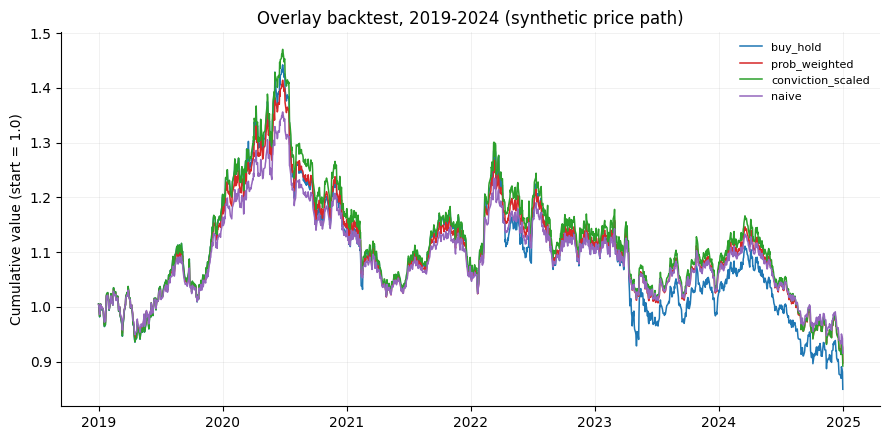

In [5]:
portfolio_returns = pd.read_csv('../artifacts_data/day13_portfolio_returns.csv', index_col=0, parse_dates=True)
cum = (1 + portfolio_returns).cumprod()
fig, ax = new_figure()
for col, color in zip(cum.columns, PALETTE):
    ax.plot(cum.index, cum[col], label=col, color=color, linewidth=1.1)
ax.set_ylabel('Cumulative value (start = 1.0)')
ax.set_title('Overlay backtest, 2019-2024 (synthetic price path)')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('../docs/artifacts/day13_backtest_cumulative.png', dpi=110)

## 3. Regime-conditioned drawdowns

In [6]:
rc_dd = pd.read_csv('../artifacts_data/day13_regime_drawdowns_overlay.csv', parse_dates=['start', 'end'])
rc_dd.sort_values('max_drawdown').head(8)

,regime,start,end,n_days,max_drawdown,total_return
22,Calm,2023-05-22,2024-12-30,421,-0.2173,-0.1390
8,Calm,2020-07-23,2021-02-11,146,-0.1479,-0.1394
10,Calm,2021-02-24,2022-02-10,252,-0.1315,0.0596
20,Calm,2022-07-11,2023-04-10,196,-0.1245,-0.0891
6,Calm,2020-06-15,2020-07-20,26,-0.1066,-0.0754
0,Calm,2019-01-01,2020-03-11,312,-0.0978,0.2480
18,Calm,2022-04-19,2022-06-28,51,-0.0767,-0.0322
2,Calm,2020-03-26,2020-05-26,44,-0.0694,0.0408


Each row is one CONTIGUOUS run of a single dominant regime label, not
all days of that label pooled together - a drawdown spanning two
unrelated Crisis episodes is not one drawdown. The worst individual
episodes are long Calm runs with a grinding decline inside them (the
model's Calm state is defined by ANNUALISED drift, not a guarantee
against drawdown within a run), which is itself a reasonable finding:
a 2-state Calm/Crisis model cannot distinguish "calm but drifting down"
from "calm and rising" within the Calm label - a real limitation of
this coarse a taxonomy.

## 4. The Post-Shock point, made concrete: two layers, not one

Section `src/backtest/overlay.py` already demonstrates, using this
project's TRUE synthetic regime definitions, that Post-Shock has the
second-highest drift of any regime (0.25 annualised) and that a
naming-based tilt rule wrongly penalises it as if it were Risk-Off. That
demonstration uses the generator's own known parameters - a clean,
controlled check. What happens with the ACTUAL FITTED model, on this
actual backtest window, is a second, genuinely different question.

In [7]:
comparison = json.load(open('../artifacts_data/day13_5state_comparison.json'))
print("Full 5-state model's OWN ESTIMATED drift by label (annualised):")
for name, d in comparison['drift_by_label_ann'].items():
    print(f"  {name:14s} {d:+.3f}")
print(f"\nDays with P(Post-Shock) > 0.5 in the 2019-2024 window: {comparison['post_shock_days_in_window']}")

Full 5-state model's OWN ESTIMATED drift by label (annualised):
  Risk-On        +0.099
  Late-Cycle     -0.028
  Transitional   -0.049
  Post-Shock     -0.809
  Risk-Off       -0.908

Days with P(Post-Shock) > 0.5 in the 2019-2024 window: 2


**The fitted model's own estimated Post-Shock drift came out
NEGATIVE (around -0.8), not the true generative +0.25.** This is a
second, compounding problem, distinct from the naming trap: a
drift/vol-aware tilt rule is only as good as the regime identification
feeding it, and Day 4 already established this 5-state HMM is weakly
identified (BIC preferred 3 states; ground-truth match rate around 40%).
Fixing the TILT RULE (risk-adjust by actual characteristics, not by
name) does not help if the MODEL's ESTIMATE of those characteristics is
itself unreliable for a rare, hard-to-identify state. With only 2 days
meeting the P(Post-Shock) > 0.5 threshold in this entire 6-year window,
this is reported as illustrative of a real risk, not as a robust,
well-powered finding - the sample is simply too small to claim more.

## 5. Monte Carlo projection and the Investment Committee artefact

In [8]:
mc = json.load(open('../artifacts_data/day13_mc_summary.json'))
print(f"Regime distribution as of 2024-12-31: Calm={mc['final_regime_dist']['Calm']:.1%}  Crisis={mc['final_regime_dist']['Crisis']:.1%}")
print(f"90% one-year prediction interval: [{mc['p90_interval'][0]:+.1%}, {mc['p90_interval'][1]:+.1%}]")
print(f"Probability of negative one-year return: {mc['prob_negative_return']:.1%}")
print(f"VaR(5%): {mc['var_5pct']:+.1%}   CVaR(5%): {mc['cvar_5pct']:+.1%}")

Regime distribution as of 2024-12-31: Calm=34.8%  Crisis=65.2%
90% one-year prediction interval: [-49.0%, +36.4%]
Probability of negative one-year return: 54.9%
VaR(5%): -49.0%   CVaR(5%): -59.2%


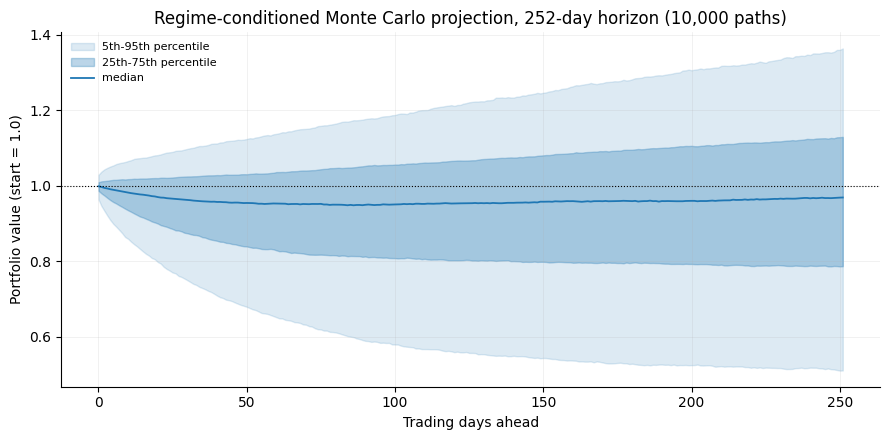

In [9]:
paths_data = np.load('../artifacts_data/day13_mc_paths.npz')
fig, ax = new_figure()
days = np.arange(252)
ax.fill_between(days, paths_data['pct_5'], paths_data['pct_95'], alpha=0.15, color=PALETTE[0], label='5th-95th percentile')
ax.fill_between(days, paths_data['pct_25'], paths_data['pct_75'], alpha=0.3, color=PALETTE[0], label='25th-75th percentile')
ax.plot(days, paths_data['pct_50'], color=PALETTE[0], linewidth=1.3, label='median')
ax.axhline(1.0, color='black', linestyle=':', linewidth=0.8)
ax.set_xlabel('Trading days ahead')
ax.set_ylabel('Portfolio value (start = 1.0)')
ax.set_title('Regime-conditioned Monte Carlo projection, 252-day horizon (10,000 paths)')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('../docs/artifacts/day13_mc_fan_chart.png', dpi=110)

In [10]:
backtest = json.load(open('../artifacts_data/day13_backtest_results.json'))
fit = backtest['point_in_time_fit']

lineage = Lineage(
    model_name='Frequentist 2-state HMM (point-in-time fit, Calm/Crisis)',
    model_fit_window=f"{fit['fit_data_range'][0]} to {fit['fit_data_range'][1]}",
    model_fit_seed=fit['seed'], n_valid_restarts=fit['n_valid_restarts'],
    simulation_seed=42, n_sims=mc['n_sims'], horizon_days=mc['horizon_days'], as_of_date='2024-12-31',
)
stmt, p_trans, worst = conditional_on_state_statement(
    paths_data['paths'], paths_data['states'], target_state=1, window_days=90,
    min_days_in_state=45, state_name='Crisis',
)
artefact = build_ic_artefact(
    lineage=lineage, final_regime_dist=mc['final_regime_dist'], p90_interval=tuple(mc['p90_interval']),
    prob_negative=mc['prob_negative_return'], p5_return=mc['p5_return'],
    var5=mc['var_5pct'], cvar5=mc['cvar_5pct'], conditional_statement=stmt,
)
print("LINEAGE:")
for k, v in artefact.lineage.__dict__.items():
    print(f"  {k}: {v}")
print("\nIC STATEMENTS:")
for s in artefact.render_ic_statements():
    print(" -", s)

LINEAGE:
  model_name: Frequentist 2-state HMM (point-in-time fit, Calm/Crisis)
  model_fit_window: 2011-01-04 to 2018-12-31
  model_fit_seed: 61
  n_valid_restarts: 30
  simulation_seed: 42
  n_sims: 10000
  horizon_days: 252
  as_of_date: 2024-12-31

IC STATEMENTS:
 - Conditional on current regime probabilities (Calm: 35%, Crisis: 65%), the 90% one-year prediction interval for the scheme is -49% to +36%.
 - Probability of negative one-year return: 55%.
 - Worst-case (5th percentile) one-year return: -49%.
 - If the regime spends at least 45 of the first 90 days in Crisis (probability: 26%), the worst-case (5%-percentile) one-year return is -63%.


## Summary

- A point-in-time-valid backtest needs point-in-time-valid parameters,
  not just point-in-time probabilities. Attempting this directly, found
  K=5 fails entirely and K=3 degenerates on 8 years of data; K=2 is the
  most this window robustly supports - independent confirmation of Day
  4's "simpler is more robust" finding, not a convenience choice.
- All three overlay variants reduce drawdown and improve the
  information ratio relative to buy-hold on this synthetic 2019-2024
  slice. The underlying price path is synthetic, not real Nifty, and
  this is restated deliberately: the real market did very differently
  over the real 2019-2024 period.
- The Post-Shock mislabelling point has two layers, not one: a naming-
  based tilt rule is wrong in principle (clean, controlled
  demonstration using true generative parameters), AND a "fixed"
  drift/vol-aware rule is only as good as the regime identification
  feeding it, which Day 4 already showed is unreliable for this HMM's
  rarer states - shown concretely, though on too small a sample (2
  days) to claim as a robust result.
- The Monte Carlo engine (A13.1/A13.2) and IC artefact (A13.3) are
  implemented with one real numerical fix (exact row-stochasticity
  before inverse-CDF sampling) and generate the exact conditional-
  statement style A13.3 asks for, each one carrying explicit, traceable
  lineage back to the model, fit window, and seed that produced it.

See `docs/day13_monte_carlo_notes.md` for the full write-up.